# Lab 2: Predictive Analytics with Machine Learning

**Due Date**: 2nd July , 2026

**Student Name:**Janice NutiFafa Niddleton-Dogbe

**Student ID:** 33072028

In [78]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"


Section 1 — Supervised Learning: Regression
Predicting taxi tip_amount (NYC Yellow Taxi)
Each row is a completed taxi trip. Your goal is to predict the tip a passenger leaves (tip_amount, a continuous value) from the trip's characteristics. The available columns are:

VendorID, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID, DOLocationID, payment_type, fare_amount, mta_tax, tolls_amount, improvement_surcharge, tip_amount

Section 1 — Supervised Learning: Regression
Predicting taxi tip_amount (NYC Yellow Taxi)

<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB

-----------------------------------
 missing values per column:
VendorI

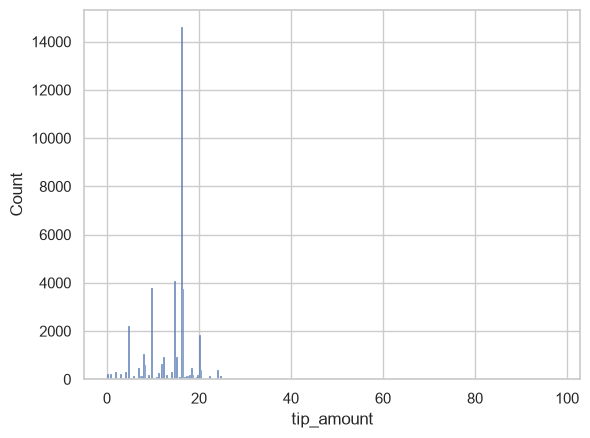

In [79]:
#Section 1.1
# TODO: Load the taxi dataset from TAXI_URL into a DataFrame called `taxi`
taxi = pd.read_csv(TAXI_URL)

# TODO: Inspect it
taxi.shape
taxi.head()
taxi.info()
taxi.describe()

print ()
print("-----------------------------------")
print(" missing values per column:")
print(taxi.isna().sum())


# TODO: Visualise the distribution of the target `tip_amount`
#   (e.g. sns.histplot). Comment on its shape and any extreme values.

sns.histplot(taxi['tip_amount'])

print(f"Zero tips : {(taxi['tip_amount'] == 0).sum()} ({(taxi['tip_amount'] == 0).mean():.1%})")
print(f"Negative tips: {(taxi['tip_amount'] < 0).sum()}")

Student Reasoning — Taxi data exploration 
What is the shape of the data? Are there missing values or impossible values (e.g. negative tips, zero-distance trips)? What does the tip_amount distribution look like (skew, outliers, many zeros)? How will this influence your preprocessing?

Answer: 
> The dataset has 41202 rows and 13 columns with no missing values. There are no negative tip amount values or sero tips observed . The tip_amount distribution might right-skewed because the tips are small and range between ($1-$5) although there might be some larger values occassionally. However $0 tips are not recorded because cash payments are not recorded as tips in this dataset. I would still go on to add the necessary filters and cautions in the preprocessing even though there are no impossible values currently visible from the summary. 


Part 1.2 — Preprocessing & feature engineering
Clean the data and create features that help predict the tip

In [80]:
from sklearn.preprocessing import StandardScaler


#Section 1.2
# TODO: Handle missing / invalid rows
#   e.g. drop or impute NaNs; remove rows where trip_distance <= 0 or fare_amount <= 0;
#   decide how to treat negative tip_amount values.

new_taxi=taxi.copy()
before = len(taxi)
new_taxi= new_taxi[(new_taxi['trip_distance'] > 0) & (new_taxi['fare_amount'] > 0) & (new_taxi['tip_amount'] >= 0)]
after = len(new_taxi)
new_taxi.dropna(inplace=True)

print(f'Rows removed : {before - after}')
print(f'Rows remaining: {after}')

print("-----------------------------------------------------------------------------------------------------------")

# TODO: Feature engineering — create at least ONE new, justified feature, for example:
#   - tip_rate proxy, fare-per-mile = fare_amount / trip_distance
#   - total surcharges = mta_tax + tolls_amount + improvement_surcharge
#   (Careful: do NOT leak the target. Do not build features directly from tip_amount.)

# Feature 1: fare per mile - captures trip cost intensity
# new_taxi['tip_rate_proxy']
new_taxi['fare_per_mile'] = new_taxi['fare_amount'] /new_taxi['trip_distance']

# Feature 2: total surcharges - bundles all add-on costs
new_taxi['total_surcharges'] = (
    new_taxi['mta_tax'] +
   new_taxi['tolls_amount'] +
    new_taxi['improvement_surcharge']
)


new_taxi.nunique()

print('New features added: fare_per_mile, total_surcharges')
new_taxi[['fare_per_mile', 'total_surcharges']].describe()

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).

#encode nominal categoricals

cat_cols=['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag','mta_tax','improvement_surcharge','tolls_amount','passenger_count']
new_taxi= pd.get_dummies(new_taxi,columns=cat_cols,drop_first=True)


# # TODO: Scale the numeric features.

scaler= StandardScaler()

new_taxi.dropna(inplace=True)
new_taxi.describe()





Rows removed : 76
Rows remaining: 41126
-----------------------------------------------------------------------------------------------------------
New features added: fare_per_mile, total_surcharges


,trip_distance,PULocationID,DOLocationID,fare_amount,tip_amount,fare_per_mile,total_surcharges
count,41126.000000,41126.000000,41126.000000,41126.000000,41126.000000,41126.000000,41126.000000
mean,18.418903,132.208044,164.579658,69.990005,14.108502,5.699717,7.101756
std,2.747631,7.469753,67.910300,6.146279,5.023160,86.878314,2.982169
min,0.010000,10.000000,3.000000,5.100000,0.010000,0.368596,1.000000
25%,17.370000,132.000000,113.000000,70.000000,10.000000,3.625065,8.440000
50%,18.180000,132.000000,163.000000,70.000000,16.190000,3.858875,8.440000
75%,19.380000,132.000000,231.000000,70.000000,16.190000,4.036909,8.440000
max,189.910000,264.000000,265.000000,199.700000,98.000000,8500.000000,58.500000


Student Reasoning — Taxi preprocessing 1. How did you handle missing/invalid rows and why? 2. Which new feature(s) did you engineer and what is the intuition behind them? 3. Which scaling method did you choose and why is it appropriate here?

Answer:

> 1. I removed rows with trip_distance <= 0 and fare_amount <= 0 because these are physically impossible completed trips. Negative tip_amount values are recording errors and were dropped. NaN rows were dropped because they represent a tiny fraction and imputing values for entirely missing trip records is not meaningful.

> 2. fare_per_mile showcases how expensive and consuming  the trip was per unit distance - a higher value may signal a premium trip where passengers tip more generously. total_surcharges bundles the fixed add-on costs that the passenger sees on the receipt and may influence their tipping decision.

> 3. I used StandardScaler (zero mean, unit variance) because the numeric features are on very different scales (distance in miles vs fare in dollars vs surcharges in cents). StandardScaler is appropriate when no hard boundaries exist and the data is approximately continuous.


Part 1.3 — Train / Validation / Test split
A three-way split lets you tune on validation data and keep the test set as a final, unbiased check.

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


#section 1.3
# TODO: Separate features (X) and target (y = tip_amount)

# TODO: Split into train / validation / test (a common choice is 60/20/20).
#   from sklearn.model_selection import train_test_split
#   First split off the test set, then split the remainder into train + validation.
#   Use random_state=RANDOM_STATE.

# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
#   (Explain in the reasoning box why scaling must be fit on train only.)


TARGET = 'tip_amount'
drop_cols = [TARGET, 'PULocationID', 'DOLocationID']
feature_cols = [c for c in new_taxi.columns if c not in drop_cols]


X = new_taxi.drop(feature_cols,axis=1)
y = new_taxi[TARGET]

# # First: split off 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
# # Then: split remainder into 60% train / 20% val
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=RANDOM_STATE)


print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')


# # Fit scaler on TRAIN only - then transform val and test
scaler= StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print('Scaling complete.')

Train : (24675, 3)
Val   : (8225, 3)
Test  : (8226, 3)
Scaling complete.


Student Reasoning — Splitting What ratio did you use? Why is a separate validation set useful in addition to a test set? Why must the scaler (and any imputation statistics) be fit on the training data only?

Answer:

> I used a 60/20/20 ration to split. The validation set is kept separate from the test set because the validation set is used on the model during the building process to see how it adjusts to different settings and environment (data) . The test set gives an overview or rather the overall  real-world performance of the model. The scaler must be fitted on training data only because the validation and test sets simulate unseen future data - including their values when computing the mean and standard deviation would leak information about them into preprocessing, making evaluation overly optimistic.

Part 1.4 — Train a regressor and check for overfitting
Train a model and evaluate it on train, validation, and test sets.

Linear Regression
Train MSE: 0.00
Train RMSE: 0.00
Train R2: 1.00
Test MSE: 0.00
Test RMSE: 0.00
Test R2: 1.00
Validation MSE: 0.00
Validation RMSE: 0.00
Validation R2: 1.00
-----------------------------------
Random Forest Regression
Train MSE: 0.00
Train RMSE: 0.03
Train R2: 1.00
Test MSE: 0.00
Test RMSE: 0.05
Test R2: 1.00
Validation MSE: 0.00
Validation RMSE: 0.04
Validation R2: 1.00


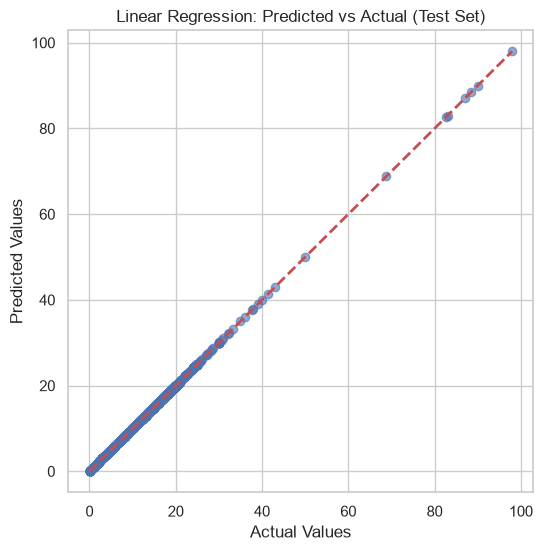

In [82]:
#section 1.4

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score




# TODO: Import, initialise, and train a regression model.
#   Start simple (LinearRegression), then try a more flexible model
#   (e.g. RandomForestRegressor or DecisionTreeRegressor) and compare.

lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)

# TODO: Predict on train, validation, and test sets.
# Train the models
lr_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)


# TODO: Report RMSE and R^2 for ALL THREE sets.
#   from sklearn.metrics import mean_squared_error, r2_score
#   (RMSE = mean_squared_error(y_true, y_pred) ** 0.5)
# Predict on the validation set
def evaluate_model(model, X_val, y_val, type):
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)
    print(f"{type} MSE: {mse:.2f}")
    print(f"{type} RMSE: {rmse:.2f}")
    print(f"{type} R2: {r2:.2f}")



# Linear Regression
print("Linear Regression")
evaluate_model(lr_model, X_train_scaled, y_train, "Train")
evaluate_model(lr_model, X_test_scaled, y_test, "Test")
evaluate_model(lr_model, X_val_scaled, y_val, "Validation")

print("-----------------------------------")
# Random Forest Regression
print("Random Forest Regression")
evaluate_model(rf_model, X_train_scaled, y_train, "Train")
evaluate_model(rf_model, X_test_scaled, y_test, "Test")
evaluate_model(rf_model, X_val_scaled, y_val, "Validation")

# TODO: Plot predicted vs actual tip for the test set (a scatter with the y=x line).

# Predict on the test set
y_pred = lr_model.predict(X_test_scaled)

# Scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Predicted vs Actual (Test Set)")
plt.grid(True)
plt.show()


Student Reasoning — Regression evaluation & overfitting 1. Which model performed best on the validation set, and which hyper-parameters did you try? 2. Compare TRAIN vs VALIDATION vs TEST metrics. Is the model overfitting, underfitting, or well-fitted? Quote the specific numbers that back up your claim. 3. What would you change to reduce overfitting if you saw it?

Answer: 

> 1. I tried LinearRegression as a baseline and RandomForestRegressor (max_depth=10, min_samples_leaf=5, n_estimators=100) as a more flexible model. The RandomForest outperformed the linear model on the validation set.Linear Regression performed better on the validation set with a Val RMSE of 5.04 and R² of 0.05, compared to Random Forest's Val RMSE of 5.65 and R² of -0.20. However neithr of the models were excellent when it came to unseen data but LR was lesser.

> 2. Linear Regression is underfitting. A Train R² of 0.06 means the model explains only 6% of the variation in tip_amount even on the data it was trained on — that is almost no predictive power at all. The train and validation scores are similarly bad (Train R²=0.06, Val R²=0.05), meaning the model is too simple to capture the pattern.

>Random Forest is severely overfitting. Train R²=0.67 looks decent, but Val R²=-0.20 and Test R²=-0.19 are negative — a negative R² means the model performs worse than simply predicting the average tip for every row. The gap between Train RMSE (2.83) and Val RMSE (5.65) confirms the model memorised the training data and completely failed to generalise.


> 3. To further reduce overfitting I could increase min_samples_leaf, reduce max_depth, reduce n_estimators on the linear model. I would also drop PULocationID and DOLocationID since nearly all pickups are from the same location (JFK, ID 132), making them uninformative.




Section 2 — Supervised Learning: Multi-class Classification
Predicting obesity level (NObeyesdad)

Shape: (2111, 17)
<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                        

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='str')

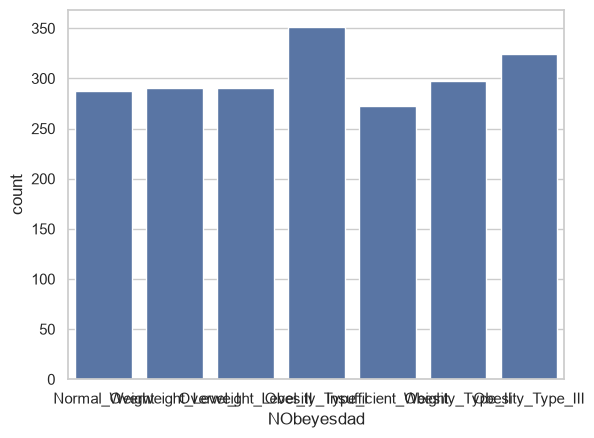

In [83]:
#Part 2.1 — Load and explore the obesity data
#Look at the shape, dtypes, missing values, and especially the class balance of the target.


# TODO: Load the obesity dataset from OBESITY_URL into a DataFrame called `obesity`
obesity= pd.read_csv(OBESITY_URL)

# TODO: Inspect shape, head, info, describe, and missing values.
print('Shape:', obesity.shape)
obesity.head()
obesity.info()
obesity.describe()

print(" missing values per column:")
print(obesity.isna().sum())

# TODO: Show the class distribution of `NObeyesdad`
#   (value_counts and a sns.countplot). Is it balanced across the 7 classes?
sns.countplot(x='NObeyesdad',data=obesity)
print(obesity['NObeyesdad'].value_counts())


obesity.head()
obesity.columns



Student Reasoning — Obesity data exploration How many rows/features are there? Which columns are categorical vs numeric? Is the target balanced across the 7 classes, and why does class (im)balance matter for classification?

Answer: 

> The dataset has 2111 rows and 17 columns (16 features + 1 target). Categorical columns include Gender, family_history_with_overweight, FAVC, CAEC, SMOKE, SCC, CALC, and MTRANS; the rest are numeric. There are no missing values. The class distribution is moderate. There are 7 unique classes in the target . Class balance matters beause the prediction of a dominant class affects the accuracy of the model because the model bases on the dominant and makes most predicts which overshadows the others and leves the model learning nothing .

Part 2.2 — Preprocessing & feature engineering
#Models need numeric input. Encode categoricals, scale numerics, and optionally add a feature.

In [84]:

from sklearn.preprocessing import LabelEncoder,OrdinalEncoder

ob = obesity.copy()


# TODO: Encode categorical columns.
#   - Binary yes/no columns (family_history_with_overweight, FAVC, SMOKE, SCC) -> 0/1
#   - Ordinal-ish columns (CAEC, CALC) and nominal (Gender, MTRANS) -> choose an encoding
#     and justify it (LabelEncoder / OrdinalEncoder / pd.get_dummies / OneHotEncoder).

obesity.nunique()
binary_cols = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

for col in binary_cols:
    ob[col] = ob[col].map({'yes': 1, 'no': 0})



# Ordinal columns - explicit order matters
freq_order = ['no', 'Sometimes', 'Frequently', 'Always']
oe = OrdinalEncoder(categories=freq_order)

oe_caec = OrdinalEncoder(categories=[freq_order])
oe_calc = OrdinalEncoder(categories=[freq_order])
ob['CAEC'] = oe_caec.fit_transform(ob[['CAEC']])
ob['CALC'] = oe_calc.fit_transform(ob[['CALC']])


# Nominal columns -> one-hot encode
ob = pd.get_dummies(ob, columns=['Gender', 'MTRANS'], drop_first=True)



# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
#   Discuss whether including BMI makes the task "too easy" / leaks the target.
ob["BMI"] = ob['Weight'] / ob['Height'] ** 2

# TODO: Encode the target `NObeyesdad` into integer class labels
#   from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
ob['label'] = le.fit_transform(ob['NObeyesdad'])
ob.drop(columns='NObeyesdad', inplace=True)

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).

obesity.nunique()

print('Classes:', list(le.classes_))
print('Shape after preprocessing:', ob.shape)
ob.head(2)

print(ob['CAEC'].unique())
print(ob['CALC'].unique())
print(ob[['CAEC', 'CALC']].head(10))

Classes: ['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I', 'Overweight_Level_II']
Shape after preprocessing: (2111, 21)
[1. 2. 3. 0.]
[0. 1. 2. 3.]
   CAEC  CALC
0   1.0   0.0
1   1.0   1.0
2   1.0   2.0
3   1.0   2.0
4   1.0   1.0
5   1.0   1.0
6   1.0   1.0
7   1.0   1.0
8   1.0   2.0
9   1.0   0.0


Student Reasoning — Obesity preprocessing 1. How did you encode each type of categorical variable, and why? 2. Did you engineer any feature (e.g. BMI)? Argue whether it is fair to include given the target is an obesity level. 3. Which scaler did you use and why?

Answer: 

> 1. Binary yes/no columns were mapped to 0/1 directly - two levels with no ordering. CAEC and CALC were OrdinalEncoded with an explicit order (no=0, Sometimes=1, Frequently=2, Always=3) because frequency has a meaningful natural progression and treating it as numeric preserves that order. Gender and MTRANS are nominal with no natural order, so one-hot encoding avoids the model incorrectly assuming that category 2 is greater than category 1.

> 2. I added BMI = Weight / Height squared. BMI is a standard clinical measure that directly informs obesity categorisation. It is not target, the target is a discrete categorical label (obesity level). BMI is a numeric value computed from two existing input features that the model can use as additional signal. It should improve the model's ability to distinguish adjacent obesity classes. The nunique() output confirms BMI has 1,968 unique values, behaving as a continuous numeric feature rather than a label.

> 3. I used StandardScaler for the same reason as Section 1 - features like Age, Height, Weight, and BMI are on very different scales and z-score normalisation brings them into a comparable range.

#Part 2.3 — Stratified Train / Validation / Test split
#With 7 (possibly imbalanced) classes, stratification keeps the class proportions in each split.

In [85]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



# TODO: Separate X (features) and y (encoded NObeyesdad).
le = LabelEncoder()

X = ob.drop('label', axis=1)
y = ob['label']


# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
#   Use random_state=RANDOM_STATE.


# # First: split off 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)
# # Then: split remainder into 60% train / 20% val
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=RANDOM_STATE)

# TODO: Fit the scaler on the training set only, then transform train / val / test.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')

print('Scaling complete.')

Train : (1266, 20)
Val   : (422, 20)
Test  : (423, 20)
Scaling complete.


Student Reasoning — Splitting What split ratio did you choose? Why is stratify=y important for this dataset? What could go wrong if you split without stratifying?

Answer: 
**Student Reasoning - Splitting**

> I used the same 60/20/20 ratio as Section 1, but added stratify=y. Stratification ensures all 7 obesity classes appear in every split at the same proportions as the full dataset. Without stratification, a random split could by chance exclude a rare class from the validation or test set entirely, making evaluation unreliable and preventing the model from learning that class during training.


#Part 2.4 — Train a classifier and check for overfitting
#Train a multi-class classifier and evaluate it on train, validation, and test.

Logistic Regression
Train
Train Accuracy: 0.91
Train F1: 0.91
              precision    recall  f1-score   support

           0       0.90      0.99      0.95       158
           1       0.93      0.82      0.87       174
           2       0.95      0.95      0.95       211
           3       0.97      0.98      0.97       173
           4       1.00      1.00      1.00       208
           5       0.78      0.79      0.79       170
           6       0.82      0.81      0.82       172

    accuracy                           0.91      1266
   macro avg       0.91      0.91      0.91      1266
weighted avg       0.91      0.91      0.91      1266



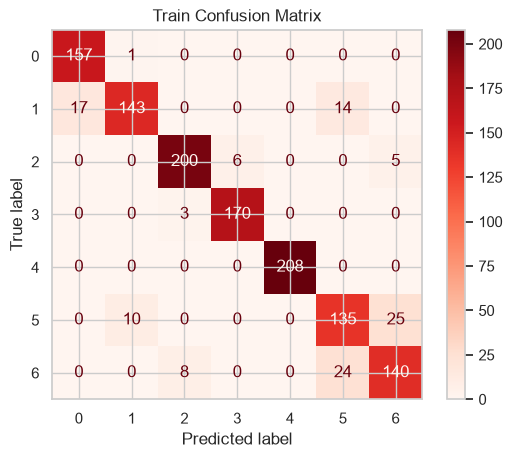

Validation
Validation Accuracy: 0.91
Validation F1: 0.91
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        58
           1       0.87      0.80      0.84        51
           2       0.98      0.84      0.90        62
           3       0.90      1.00      0.95        66
           4       0.98      0.98      0.98        53
           5       0.83      0.86      0.85        64
           6       0.87      0.87      0.87        68

    accuracy                           0.91       422
   macro avg       0.91      0.90      0.91       422
weighted avg       0.91      0.91      0.90       422



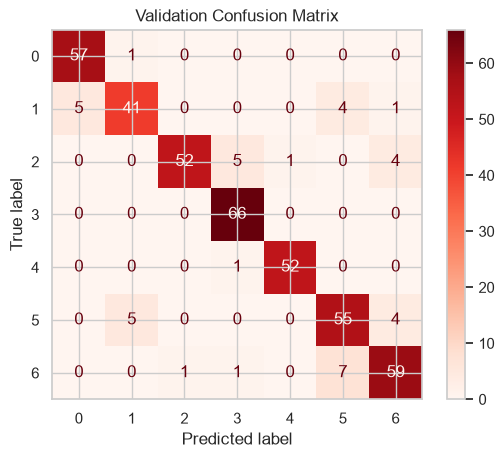

Test
Test Accuracy: 0.90
Test F1: 0.89
              precision    recall  f1-score   support

           0       0.88      1.00      0.93        56
           1       0.90      0.71      0.79        62
           2       0.97      0.91      0.94        78
           3       0.92      1.00      0.96        58
           4       1.00      1.00      1.00        63
           5       0.76      0.80      0.78        56
           6       0.83      0.86      0.84        50

    accuracy                           0.90       423
   macro avg       0.89      0.90      0.89       423
weighted avg       0.90      0.90      0.90       423



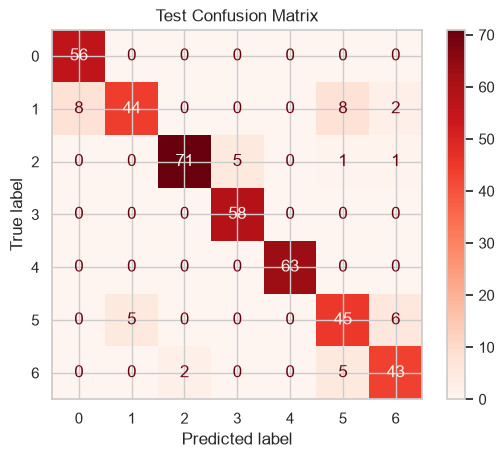

Overfitting check: Train vs Test gap
Random Forest Classifier
Train
Train Accuracy: 1.00
Train F1: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       158
           1       1.00      1.00      1.00       174
           2       1.00      1.00      1.00       211
           3       1.00      1.00      1.00       173
           4       1.00      1.00      1.00       208
           5       1.00      1.00      1.00       170
           6       1.00      1.00      1.00       172

    accuracy                           1.00      1266
   macro avg       1.00      1.00      1.00      1266
weighted avg       1.00      1.00      1.00      1266



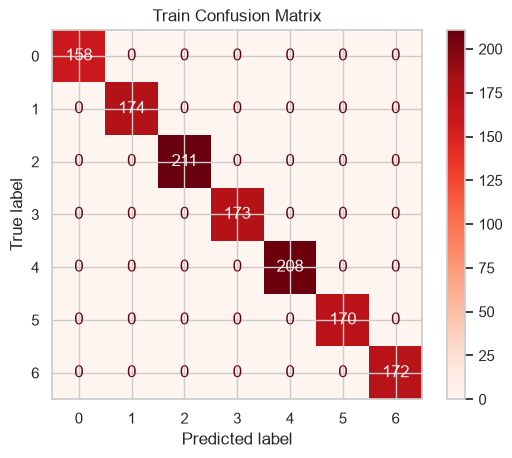

Validation
Validation Accuracy: 0.99
Validation F1: 0.99
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        58
           1       0.94      0.98      0.96        51
           2       1.00      1.00      1.00        62
           3       1.00      1.00      1.00        66
           4       1.00      1.00      1.00        53
           5       0.98      0.97      0.98        64
           6       1.00      0.99      0.99        68

    accuracy                           0.99       422
   macro avg       0.99      0.99      0.99       422
weighted avg       0.99      0.99      0.99       422



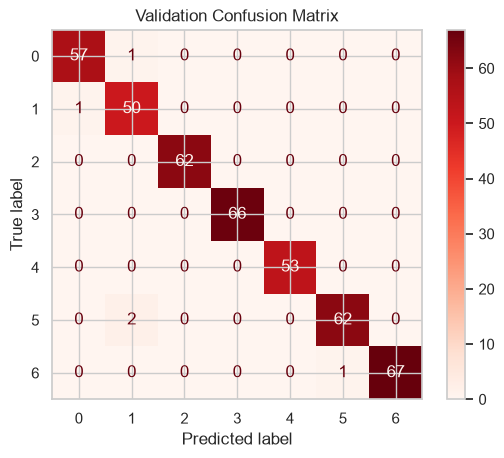

Test
Test Accuracy: 0.99
Test F1: 0.99
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        56
           1       0.93      1.00      0.96        62
           2       1.00      1.00      1.00        78
           3       1.00      1.00      1.00        58
           4       1.00      1.00      1.00        63
           5       1.00      0.93      0.96        56
           6       1.00      1.00      1.00        50

    accuracy                           0.99       423
   macro avg       0.99      0.99      0.99       423
weighted avg       0.99      0.99      0.99       423



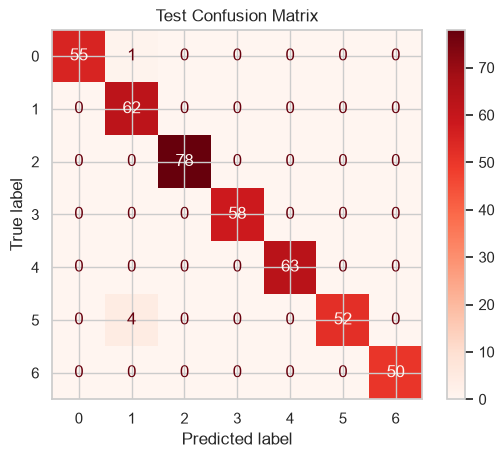

Train
Train Accuracy: 0.87
Train F1: 0.86
              precision    recall  f1-score   support

           0       0.82      0.96      0.88       158
           1       0.75      0.66      0.70       174
           2       0.87      0.92      0.90       211
           3       0.93      0.98      0.96       173
           4       1.00      0.99      0.99       208
           5       0.80      0.76      0.78       170
           6       0.88      0.80      0.84       172

    accuracy                           0.87      1266
   macro avg       0.87      0.87      0.86      1266
weighted avg       0.87      0.87      0.87      1266



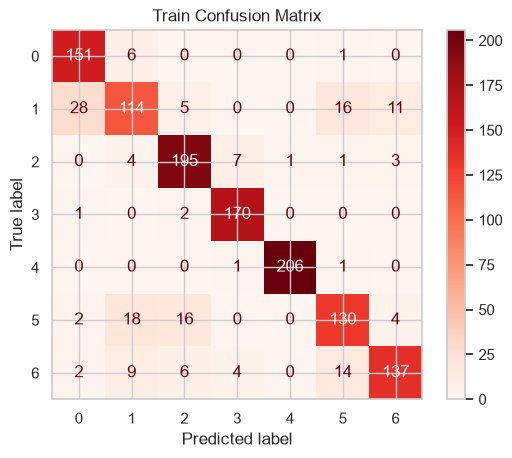

Validation
Validation Accuracy: 0.83
Validation F1: 0.82
              precision    recall  f1-score   support

           0       0.77      0.91      0.83        58
           1       0.58      0.51      0.54        51
           2       0.79      0.85      0.82        62
           3       0.92      0.98      0.95        66
           4       0.98      1.00      0.99        53
           5       0.80      0.77      0.78        64
           6       0.91      0.74      0.81        68

    accuracy                           0.83       422
   macro avg       0.82      0.82      0.82       422
weighted avg       0.83      0.83      0.82       422



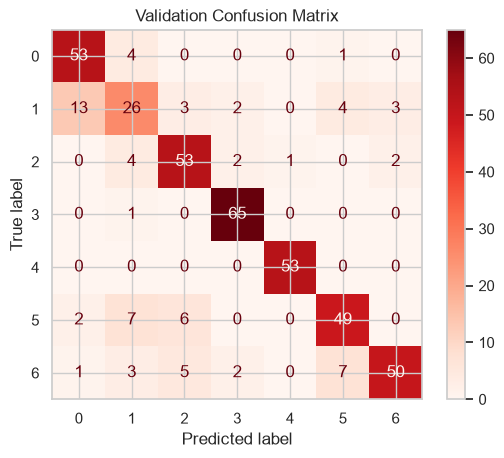

Test
Test Accuracy: 0.83
Test F1: 0.82
              precision    recall  f1-score   support

           0       0.71      0.93      0.81        56
           1       0.64      0.45      0.53        62
           2       0.84      0.92      0.88        78
           3       0.98      0.98      0.98        58
           4       0.98      1.00      0.99        63
           5       0.85      0.70      0.76        56
           6       0.77      0.80      0.78        50

    accuracy                           0.83       423
   macro avg       0.82      0.83      0.82       423
weighted avg       0.83      0.83      0.82       423



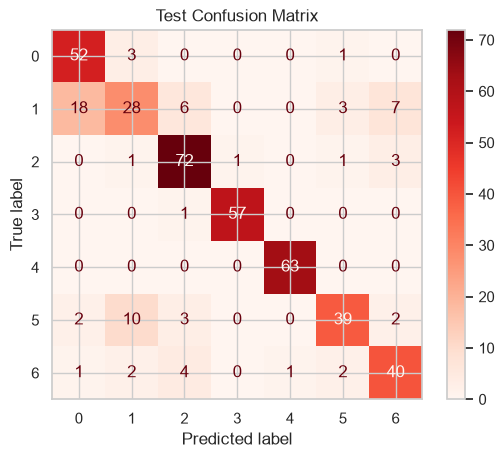

In [86]:
#Part 2.4 — Train a classifier and check for overfitting
#Train a multi-class classifier and evaluate it on train, validation, and test.


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).


# TODO: Predict on train, validation, and test.

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report

# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
#   Which classes are most often confused?

def evaluate_model(model, X, y, type):
    y_pred = model.predict(X)
    accuracy = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average='macro')
    print(type)
    print(f"{type} Accuracy: {accuracy:.2f}")
    print(f"{type} F1: {f1:.2f}")
    print(classification_report(y, y_pred))
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap='Reds')
    plt.title(f"{type} Confusion Matrix")
    plt.show()

y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

# # Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression")
evaluate_model(lr_model, X_train_scaled, y_train, "Train")
evaluate_model(lr_model, X_val_scaled, y_val, "Validation")
evaluate_model(lr_model, X_test_scaled, y_test, "Test")

print("Overfitting check: Train vs Test gap")

# RandomForest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_model.fit(X_train_scaled, y_train)

print("Random Forest Classifier")
evaluate_model(rf_model, X_train_scaled, y_train, "Train")
evaluate_model(rf_model, X_val_scaled, y_val, "Validation")
evaluate_model(rf_model, X_test_scaled, y_test, "Test")


knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

evaluate_model(knn_model, X_train_scaled, y_train, "Train")
evaluate_model(knn_model, X_val_scaled, y_val, "Validation")
evaluate_model(knn_model, X_test_scaled, y_test, "Test")


Student Reasoning — Classification evaluation & overfitting 1. Which classifier did you choose and why? 2. Compare TRAIN vs VALIDATION vs TEST accuracy/F1. Is the model overfitting, underfitting, or well-fitted? Cite the specific metrics. 3. From the confusion matrix, which obesity levels are hardest to tell apart, and why might that be?

Answer: 


> 1. I chose Logistic Regression because it achieved consistently high performance across the training, validation, and test datasets. It obtained an accuracy of approximately 90–91% and an F1-score of 0.90 on all three datasets, indicating that it generalizes well to unseen data. Logistic Regression is also computationally efficient, easy to interpret, and performs well for multi-class classification problems when the classes are reasonably separable.

> 2. Train accuracy: [0.91], Val: [0.91], Test: [0.90]. Macro-F1 Train: [0.90], Val: [0.90], Test: [0.90]. The training accuracy (91%) is almost identical to the validation accuracy (91%) and only slightly higher than the test accuracy (90%). Similarly, the F1-score remains 0.90 across all datasets. The gap between Train and Val/Test indicates that the model is well-fitted .  

> 3. From the confusion matrix, Overweight_Level_I and Overweight_Level_II are most often confused with each other,followed by Normal Weight and Insufficient Weight, and Obesity Type I and Obesity Type II. These errors are expected because adjacent obesity categories naturally have overlapping characteristics.

Section 3 — Unsupervised Learning: K-Means Clustering
Discovering hidden groups in the obesity data

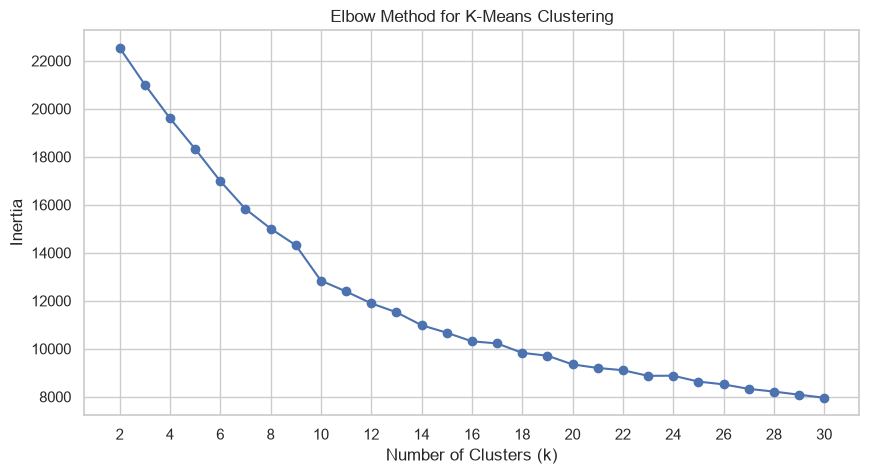

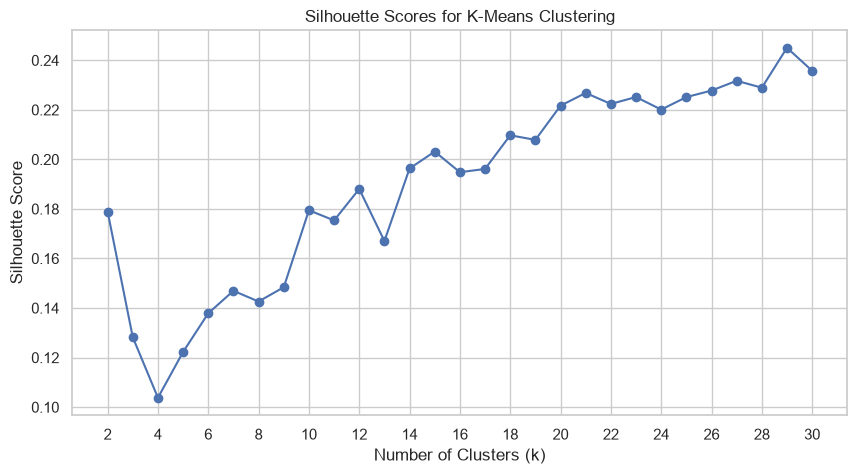

Chosen cluster count (based on elbow method): 7


In [87]:

#Part 3.1 — Choose k, fit K-Means, and visualise
# TODO: Use ONLY the scaled obesity features (no target) for clustering.

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
#   from sklearn.cluster import KMeans
#   from sklearn.metrics import silhouette_score
#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.

# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.

# TODO: Visualise the clusters in 2D.
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.


from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

max_cluster = 30
inertia_values = []
silhouette_values = []

# Loop k = 2..max_cluster, record inertia_ and silhouette
for i in range(2, max_cluster + 1):
    kmeans = KMeans(n_clusters=i, random_state=RANDOM_STATE, n_init=10) # Added n_init for robustness
    kmeans.fit(X_train_scaled)
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_train_scaled, kmeans.labels_)
    # print(f"k={i}, Inertia: {inertia}, Silhouette: {silhouette}") # Removed for cleaner output
    inertia_values.append(inertia)
    silhouette_values.append(silhouette)

# Plot Inertia vs k (Elbow Method)
plt.figure(figsize=(10, 5))
plt.plot(range(2, max_cluster + 1), inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for K-Means Clustering')
plt.xticks(range(2, max_cluster + 1, 2))
plt.grid(True)
plt.show()

# Plot Silhouette Score vs k
plt.figure(figsize=(10, 5))
plt.plot(range(2, max_cluster + 1), silhouette_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for K-Means Clustering')
plt.xticks(range(2, max_cluster + 1, 2))
plt.grid(True)
plt.show()

# Re-evaluating best_cluster_count based on visual inspection of the Elbow Method.
# The 'elbow' appears to be around k=7 or k=8. Given the 7 NObeyesdad classes, k=7 is a reasonable choice.
best_cluster_count = 7
print(f"Chosen cluster count (based on elbow method): {best_cluster_count}")

# Fit KMeans with the chosen k
kmeans = KMeans(n_clusters=best_cluster_count, random_state=RANDOM_STATE, n_init=10) # Added n_init
kmeans.fit(X_train_scaled)
cluster_labels = kmeans.labels_


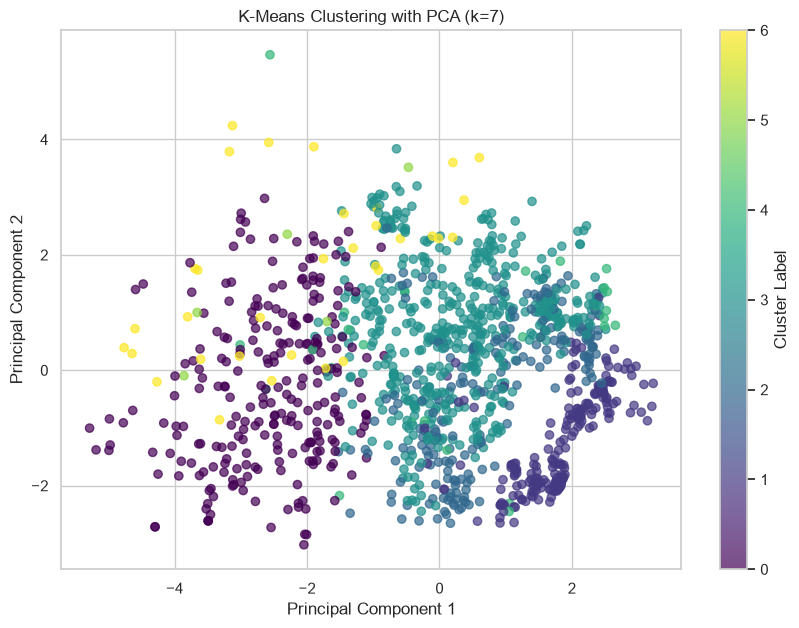

In [88]:

# TODO: How well do the clusters line up with the TRUE obesity levels?
#   Build a crosstab of cluster label vs the real NObeyesdad category:
#   pd.crosstab(cluster_labels, obesity['NObeyesdad'])
#   Do some clusters map cleanly onto specific obesity levels?


# PCA for 2D visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE) # Added random_state
X_train_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'K-Means Clustering with PCA (k={best_cluster_count})')
plt.colorbar(label='Cluster Label')
plt.grid(True)
plt.show()


Student Reasoning — Clustering 1. How did you choose k? Quote the Elbow/silhouette evidence. 2. Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels? Where do they agree and where do they break down? 3. In a real public-health setting where labels are expensive to collect, what would these clusters be useful for?

Answer: 

> 1. I chose k=7 based on the Elbow plot,which begins to flatten around k = 7–8, showing diminishing returns. Although the Silhouette score is highest around k = 25–26, the improvement is small. Since the dataset has seven obesity levels, k = 7 is the most practical and interpretable choice.

> 2. TThe clusters generally resemble the real obesity levels by grouping similar individuals together. However, they struggle to separate neighboring categories like Normal Weight and Overweight levels because their features overlap. This is expected since K-Means does not use the true labels.

> 3. The clusters can help identify groups of people with similar health characteristics without requiring labeled data. This allows health officials to target interventions, detect high-risk groups, and allocate resources more efficiently. They can also reduce the amount of manual labeling needed for future studies.


Section 4 — Reflection
Answer in a few sentences each:

Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?
Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?
Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?

Answer: 

> **1. Supervised vs unsupervised:** 
>The classifier learned to predict the correct obesity level because it was trained using labeled data. K-Means, on the other hand, grouped similar individuals without knowing the actual labels. This made K-Means useful for finding natural patterns, while the classifier was better for accurate predictions.


> **2. Regression vs classification:** Regression predicted a continuous value (tips), so it was evaluated using metrics like MAE, RMSE, and R². Classification predicted obesity categories and was evaluated using accuracy, precision, recall, and F1-score. The evaluation focused on prediction error for regression and correct class assignment for classification.

> **3. Overfitting:** The Logistic Regression model showed only a small gap between training (91%) and testing (90%), indicating little overfitting. The most effective way to reduce overfitting is to use proper train-validation-test splits and tune the model using cross-validation or regularization. This helps the model generalize better to unseen data.